In [2]:
import pandas as pd
import numpy as np
import optuna

import lightgbm as lgb
from sklearn.ensemble import HistGradientBoostingClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_recall_curve, auc
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt

c:\Users\Damien\.conda\envs\DS4SC\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Import des données

In [3]:
df = pd.read_csv("../../data/resample_normalized_flagged_v3.csv")

## Préparation des données

In [4]:
df = df.drop(columns=["apogee_id", "STARFLAGS"])

class_columns = ['class_spectral', 'class_lum_logg', 'class_lum_jhk', 'class_lum_bins_logg', 'class_lum_bins_jhk']

chemical_columns = ['C_FE', 'CI_FE', 'N_FE', 'O_FE', 'NA_FE', 'MG_FE', 'AL_FE', 'SI_FE', 'S_FE', 'K_FE', 'CA_FE', 'TI_FE', 'V_FE', 'CR_FE', 'MN_FE', 'NI_FE', 'FE_H']
physique_columns = ['J', 'H', 'K', 'LOGG', 'M_H', 'VMICRO', 'VMACRO']

df_chem = df.drop(columns=physique_columns)
df_phys = df.drop(columns=chemical_columns)

In [5]:
target_column = 'class_spectral'
X = df_chem.drop(columns=class_columns)
y = df_chem[target_column]

In [6]:
# Calcul des fréquences des classes
frequencies = df_chem[target_column].value_counts(normalize=True)

# Calcul des poids inverses
weights = (1 / frequencies).to_dict()

### Implémentation de LightGBM

In [7]:
# Division en ensemble d'entraînement et de test
X_train_LGB, X_test_LGB, y_train_LGB, y_test_LGB = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

lgb_model = lgb.LGBMClassifier(n_estimators=2000, learning_rate=0.05, class_weight=weights, random_state=42, objective="multiclass", num_class=3)

lgb_model.fit(X_train_LGB, y_train_LGB, eval_set=[(X_test_LGB, y_test_LGB)])

y_pred_LGB = lgb_model.predict(X_test_LGB)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.024432 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4335
[LightGBM] [Info] Number of data points in the train set: 363161, number of used features: 17
[LightGBM] [Info] Start training from score -1.098620
[LightGBM] [Info] Start training from score -1.098604
[LightGBM] [Info] Start training from score -1.098613


In [8]:
#évaluation du modèle
print("Accuracy : \n", accuracy_score(y_test_LGB, y_pred_LGB))
print("Classification Report : \n", classification_report(y_test_LGB, y_pred_LGB))

Accuracy : 
 0.9377140906036942
Classification Report : 
               precision    recall  f1-score   support

           F       0.78      0.87      0.82      4882
           G       0.82      0.88      0.85     18232
           K       0.98      0.96      0.97     67677

    accuracy                           0.94     90791
   macro avg       0.86      0.90      0.88     90791
weighted avg       0.94      0.94      0.94     90791



In [9]:
f1_LGB = f1_score(y_test_LGB, y_pred_LGB, average="weighted")  # "weighted" pour prendre en compte le déséquilibre
print("F1 Score:", f1_LGB)

F1 Score: 0.9390417829025344


In [10]:
y_probs_LGB = lgb_model.predict_proba(X_test_LGB)  # Probabilités prédites des classes

auc_pr_list_LGB = []
for idx, class_name in enumerate(np.unique(y_test_LGB)):
    # Créer une version binaire de y_test_CB : 1 pour la classe courante, 0 pour les autres
    y_true_binary = (y_test_LGB == class_name).astype(int)

    # Précision-Rappel
    precision, recall, _ = precision_recall_curve(y_true_binary, y_probs_LGB[:, idx])

    # Calculer l'AUC-PR
    auc_pr = auc(recall, precision)

    # Ajouter à la liste
    auc_pr_list_LGB.append(auc_pr)
auc_pr_LGB = np.mean(auc_pr_list_LGB)  # Moyenne sur toutes les classes
print("AUC-PR (moyenne sur classes):", auc_pr_LGB)

AUC-PR (moyenne sur classes): 0.9468093934120119


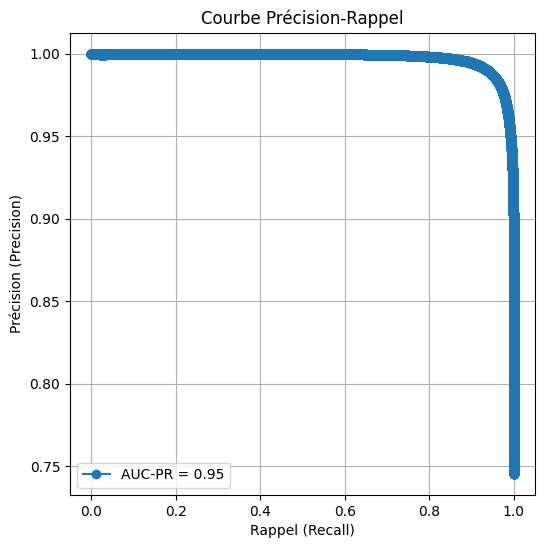

In [11]:
# Tracé de la courbe PR
plt.figure(figsize=(6, 6))
plt.plot(recall, precision, marker='o', label=f'AUC-PR = {auc_pr_LGB:.2f}')
plt.xlabel('Rappel (Recall)')
plt.ylabel('Précision (Precision)')
plt.title('Courbe Précision-Rappel')
plt.legend()
plt.grid()
plt.show()

### Implémentation de HistGradientBoosting

In [12]:
# Division en ensemble d'entraînement et de test
X_train_HGB, X_test_HGB, y_train_HGB, y_test_HGB = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

sample_weights = compute_sample_weight(class_weight=weights, y=y_train_HGB)

# Initialisation du modèle
hgb = HistGradientBoostingClassifier(loss="log_loss", learning_rate=0.1, max_iter=100)

# Entraînement
hgb.fit(X_train_HGB, y_train_HGB, sample_weight=sample_weights)

# Prédiction
y_pred_HGB = hgb.predict(X_test_HGB)

In [13]:
# Évaluation
print("Accuracy:", accuracy_score(y_test_HGB, y_pred_HGB))
print("Classification Report:\n", classification_report(y_test_HGB, y_pred_HGB))

Accuracy: 0.9206859710764282
Classification Report:
               precision    recall  f1-score   support

           F       0.69      0.90      0.78      4882
           G       0.78      0.84      0.81     18232
           K       0.98      0.94      0.96     67677

    accuracy                           0.92     90791
   macro avg       0.82      0.90      0.85     90791
weighted avg       0.93      0.92      0.92     90791



In [14]:
f1_HGB = f1_score(y_test_HGB, y_pred_HGB, average="weighted")  # "weighted" pour prendre en compte le déséquilibre
print("F1 Score:", f1_HGB)

F1 Score: 0.9232846094125117


In [15]:
y_probs_HGB = hgb.predict_proba(X_test_HGB)  # Probabilités prédites des classes

auc_pr_list_HGB = []
for idx, class_name in enumerate(np.unique(y_test_HGB)):
    # Créer une version binaire de y_test_CB : 1 pour la classe courante, 0 pour les autres
    y_true_binary = (y_test_HGB == class_name).astype(int)

    # Précision-Rappel
    precision, recall, _ = precision_recall_curve(y_true_binary, y_probs_HGB[:, idx])

    # Calculer l'AUC-PR
    auc_pr = auc(recall, precision)

    # Ajouter à la liste
    auc_pr_list_HGB.append(auc_pr)
auc_pr_HGB = np.mean(auc_pr_list_HGB)  # Moyenne sur toutes les classes
print("AUC-PR (moyenne sur classes):", auc_pr_HGB)

AUC-PR (moyenne sur classes): 0.9273512130497842


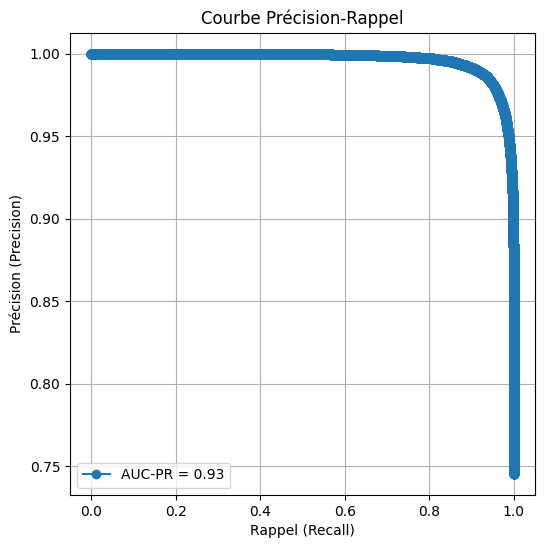

In [16]:
# Tracé de la courbe PR
plt.figure(figsize=(6, 6))
plt.plot(recall, precision, marker='o', label=f'AUC-PR = {auc_pr_HGB:.2f}')
plt.xlabel('Rappel (Recall)')
plt.ylabel('Précision (Precision)')
plt.title('Courbe Précision-Rappel')
plt.legend()
plt.grid()
plt.show()

### Implémentation de CatBoost

In [17]:
# Division en ensemble d'entraînement et de test
X_train_CB, X_test_CB, y_train_CB, y_test_CB = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Création et entraînement du modèle
model_catboost = CatBoostClassifier(iterations=1000, learning_rate=0.05, depth=10, loss_function='MultiClass',  eval_metric='MultiClass', class_weights=weights, verbose=100)

model_catboost.fit(X_train_CB, y_train_CB, eval_set=(X_test_CB, y_test_CB), early_stopping_rounds=100, plot=True, verbose=True)

# Prédictions
y_pred = model_catboost.predict(X_test_CB)

c:\Users\Damien\.conda\envs\DS4SC\Lib\site-packages\catboost\core.py:1536: UserWarning: To draw plots in fit() method you should install ipywidgets and ipython
  warnings.warn("To draw plots in fit() method you should install ipywidgets and ipython")


ImportError: No module named 'ipywidgets'

In [ ]:
# Performance
print("Accuracy:", accuracy_score(y_test_CB, y_pred))
print(classification_report(y_test_CB, y_pred))

In [ ]:
f1_CB = f1_score(y_test_CB, y_pred, average="weighted")  # "weighted" pour prendre en compte le déséquilibre
print("F1 Score:", f1_CB)

In [ ]:
y_probs_CB = model_catboost.predict_proba(X_test_CB)  # Probabilités prédites des classes

auc_pr_list_CB = []
for idx, class_name in enumerate(np.unique(y_test_CB)):
    # Créer une version binaire de y_test_CB : 1 pour la classe courante, 0 pour les autres
    y_true_binary = (y_test_CB == class_name).astype(int)

    # Précision-Rappel
    precision, recall, _ = precision_recall_curve(y_true_binary, y_probs_CB[:, idx])

    # Calculer l'AUC-PR
    auc_pr = auc(recall, precision)

    # Ajouter à la liste
    auc_pr_list_CB.append(auc_pr)
auc_pr_CB = np.mean(auc_pr_list_CB)  # Moyenne sur toutes les classes 
print("AUC-PR (moyenne sur classes):", auc_pr_CB)

In [ ]:
# Tracé de la courbe PR
plt.figure(figsize=(6, 6))
plt.plot(recall, precision, marker='o', label=f'AUC-PR = {auc_pr_CB:.2f}')
plt.xlabel('Rappel (Recall)')
plt.ylabel('Précision (Precision)')
plt.title('Courbe Précision-Rappel')
plt.legend()
plt.grid()
plt.show()

### Optimisation des hyperparamètres avec optuna

In [ ]:
# Division en ensemble d'entraînement et de test
X_train_LGB, X_test_LGB, y_train_LGB, y_test_LGB = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

def objective_LGB(trial):
    params = {
        'objective': 'multiclass',
        'metric': 'multi_logloss',
        'num_class': 3,
        'num_leaves': trial.suggest_int('num_leaves', 31, 255),
        'max_depth': trial.suggest_int('max_depth', 3, 16),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
    }

    lgb_model = lgb.LGBMClassifier(**params, class_weight=weights, random_state=42)
    lgb_model.fit(X_train_LGB, 
              y_train_LGB, 
              eval_set=[(X_test_LGB, y_test_LGB)], 
              )

    y_pred = lgb_model.predict(X_test_LGB)
    y_probs_LGB = lgb_model.predict_proba(X_test_LGB)

    f1 = f1_score(y_test_LGB, y_pred, average='weighted')
    auc_pr_list_LGB = []
    for idx, class_name in enumerate(np.unique(y_test_LGB)):
        # Créer une version binaire de y_test_LGB : 1 pour la classe courante, 0 pour les autres
        y_true_binary = (y_test_LGB == class_name).astype(int)
        
        # Précision-Rappel
        precision, recall, _ = precision_recall_curve(y_true_binary, y_probs_LGB[:, idx])
        
        # Calculer l'AUC-PR
        auc_pr = auc(recall, precision)
        
        # Ajouter à la liste
        auc_pr_list_LGB.append(auc_pr)
    auc_pr_LGB = np.mean(auc_pr_list_LGB)  # Moyenne sur toutes les classes


    return f1 , auc_pr_LGB

# Créer un objet d'étude Optuna
study_LGB = optuna.create_study(directions=['maximize', 'maximize'])
# Optimiser la fonction objectif
study_LGB.optimize(objective_LGB, n_trials=100, show_progress_bar=True)

[I 2025-04-01 12:10:06,163] A new study created in memory with name: no-name-3a86a45b-2488-4dd9-8543-d82831f3d5f8
  0%|          | 0/100 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014442 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4335
[LightGBM] [Info] Number of data points in the train set: 272371, number of used features: 17
[LightGBM] [Info] Start training from score -1.098630
[LightGBM] [Info] Start training from score -1.098606
[LightGBM] [Info] Start training from score -1.098601
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

  1%|          | 1/100 [00:36<1:00:07, 36.44s/it]

[I 2025-04-01 12:10:42,648] Trial 0 finished with values: [0.9441637579916745, 0.9466120877769993] and parameters: {'num_leaves': 146, 'max_depth': 7, 'learning_rate': 0.16635416672579256, 'n_estimators': 446}.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006655 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4335
[LightGBM] [Info] Number of data points in the train set: 272371, number of used features: 17
[LightGBM] [Info] Start training from score -1.098630
[LightGBM] [Info] Start training from score -1.098606
[LightGBM] [Info] Start training from score -1.098601
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

  2%|▏         | 2/100 [04:41<4:19:29, 158.87s/it]

...

[I 2025-04-01 12:43:52,259] Trial 8 finished with values: [0.9479917781015877, 0.9507724951852562] and parameters: {'num_leaves': 145, 'max_depth': 8, 'learning_rate': 0.08497366335900886, 'n_estimators': 1750}.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017285 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4335
[LightGBM] [Info] Number of data points in the train set: 272371, number of used features: 17
[LightGBM] [Info] Start training from score -1.098630
[LightGBM] [Info] Start training from score -1.098606
[LightGBM] [Info] Start training from score -1.098601
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

 10%|█         | 10/100 [41:25<8:03:37, 322.42s/it]

[I 2025-04-01 12:51:31,596] Trial 9 finished with values: [0.9489718782217464, 0.9539713258265223] and parameters: {'num_leaves': 255, 'max_depth': 15, 'learning_rate': 0.09283988245053316, 'n_estimators': 1958}.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012561 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4335
[LightGBM] [Info] Number of data points in the train set: 272371, number of used features: 17
[LightGBM] [Info] Start training from score -1.098630
[LightGBM] [Info] Start training from score -1.098606
[LightGBM] [Info] Start training from score -1.098601
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

Exception ignored on calling ctypes callback function: <function _log_callback at 0x0000013CC92C0220>
Traceback (most recent call last):
  File "c:\Users\Damien\.conda\envs\DS4SC\Lib\site-packages\lightgbm\basic.py", line 287, in _log_callback
    def _log_callback(msg: bytes) -> None:
    
KeyboardInterrupt: 


No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

In [ ]:
# Afficher les meilleurs hyperparamètres trouvés
print("Meilleur essai : ", study_LGB.best_trials[0])
print("Meilleurs hyperparamètres : ", study_LGB.best_trials[0].params)
print("Meilleur score F1 : ", study_LGB.best_trials[0].values[0])
print("Meilleur score AUC-PR : ", study_LGB.best_trials[0].values[1])

NameError: name 'study_LGB' is not defined

### Optimisation des hyperparamètres avec optuna de HistGradientBoosting

In [ ]:
# Division des données
X_train_HGB, X_test_HGB, y_train_HGB, y_test_HGB = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Poids des classes
sample_weights_HGB = compute_sample_weight(class_weight="balanced", y=y_train_HGB)

def objective_HGB(trial):
    """ Fonction d'optimisation pour Optuna """

    # Hyperparamètres à optimiser
    params = {
        "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.2),
        "max_iter": trial.suggest_int("max_iter", 100, 1000, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 100),
        "l2_regularization": trial.suggest_loguniform("l2_regularization", 1e-4, 1e-1)
    }

    # Initialisation du modèle
    model_HGB = HistGradientBoostingClassifier(loss="log_loss", **params, random_state=42)

    # Entraînement avec les poids
    model_HGB.fit(X_train_HGB, y_train_HGB, sample_weight=sample_weights_HGB)

    # Prédiction
    y_pred_HGB = model_HGB.predict(X_test_HGB)
    y_probs_HGB = model_HGB.predict_proba(X_test_HGB)

    # Calcul du F1-score pondéré (mieux adapté au déséquilibre)
    score = f1_score(y_test_HGB, y_pred_HGB, average="weighted")
    # Calcul l'AUC-PR
    auc_pr_list_HGB = []
    for idx, class_name in enumerate(np.unique(y_test_HGB)):
        # Créer une version binaire de y_test_HGB : 1 pour la classe courante, 0 pour les autres
        y_true_binary = (y_test_HGB == class_name).astype(int)
        
        # Précision-Rappel
        precision, recall, _ = precision_recall_curve(y_true_binary, y_probs_HGB[:, idx])
        
        # Calculer l'AUC-PR
        auc_pr = auc(recall, precision)
        
        # Ajouter à la liste
        auc_pr_list_HGB.append(auc_pr)
    auc_pr_HGB = np.mean(auc_pr_list_HGB)  # Moyenne sur toutes les classes

    return score, auc_pr_HGB  # Optuna va maximiser ces valeurs

# Lancer l'optimisation
study_HGB = optuna.create_study(directions=['maximize', 'maximize'])
study_HGB.optimize(objective_HGB, n_trials=50, show_progress_bar=True)

In [ ]:
# Afficher les meilleurs hyperparamètres trouvés
print("Meilleur essai : ", study_HGB.best_trials[0])
print("Meilleurs hyperparamètres : ", study_HGB.best_trials[0].params)
print("Meilleur score F1 : ", study_HGB.best_trials[0].values[0])
print("Meilleur score AUC-PR : ", study_HGB.best_trials[0].values[1])

NameError: name 'study_HGB' is not defined

### Optimisation des hyperparamètres avec optuna de CatBoost

In [ ]:
# Division des données
X_train_CB, X_test_CB, y_train_CB, y_test_CB = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Poids des classes pour gérer le déséquilibre
sample_weights_CB = compute_sample_weight(class_weight="balanced", y=y_train_CB)

def objective_CB(trial):
    """ Fonction d'optimisation pour Optuna """

    # Hyperparamètres à optimiser
    params = {
        "iterations": trial.suggest_int("iterations", 500, 2000, step=250),
        "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.2),
        "depth": trial.suggest_int("depth", 4, 12),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "bagging_temperature": trial.suggest_uniform("bagging_temperature", 0, 1),
    }

    # Création et entraînement du modèle
    model_CB = CatBoostClassifier(
        **params, 
        loss_function="MultiClass", 
        eval_metric="MultiClass", 
        verbose=0, 
        random_seed=42
    )

    model_CB.fit(X_train_CB, y_train_CB, sample_weight=sample_weights_CB, eval_set=(X_test_CB, y_test_CB), early_stopping_rounds=100, verbose=False)


    # Prédiction
    y_pred_CB = model_CB.predict(X_test_HGB)
    y_probs_CB = model_CB.predict_proba(X_test_HGB)

    # Calcul du F1-score pondéré (mieux adapté au déséquilibre)
    score = f1_score(y_test_CB, y_pred_CB, average="weighted")
    # Calcul l'AUC-PR
    auc_pr_list_CB = []
    for idx, class_name in enumerate(np.unique(y_test_CB)):
        # Créer une version binaire de y_test_CB : 1 pour la classe courante, 0 pour les autres
        y_true_binary = (y_test_CB == class_name).astype(int)
        
        # Précision-Rappel
        precision, recall, _ = precision_recall_curve(y_true_binary, y_probs_CB[:, idx])
        
        # Calculer l'AUC-PR
        auc_pr = auc(recall, precision)
        
        # Ajouter à la liste
        auc_pr_list_CB.append(auc_pr)
    auc_pr_CB = np.mean(auc_pr_list_CB)  # Moyenne sur toutes les classes

    return score, auc_pr_CB  # Optuna va maximiser ces valeurs

# Lancer l'optimisation
study_CB = optuna.create_study(directions=['maximize', 'maximize'])
study_CB.optimize(objective_CB, n_trials=50, show_progress_bar=True)

In [ ]:
# Afficher les meilleurs hyperparamètres trouvés
print("Meilleur essai : ", study_CB.best_trials[0])
print("Meilleurs hyperparamètres : ", study_CB.best_trials[0].params)
print("Meilleur score F1 : ", study_CB.best_trials[0].values[0])
print("Meilleur score AUC-PR : ", study_CB.best_trials[0].values[1])

Meilleur essai :  FrozenTrial(number=20, state=1, values=[0.9447011479423425, 0.948688469095485], datetime_start=datetime.datetime(2025, 3, 29, 18, 21, 46, 727552), datetime_complete=datetime.datetime(2025, 3, 29, 18, 30, 6, 662731), params={'iterations': 750, 'learning_rate': 0.16148844591009792, 'depth': 11, 'border_count': 249, 'bagging_temperature': 0.7190949337526314}, user_attrs={}, system_attrs={'nsga2:generation': 0}, intermediate_values={}, distributions={'iterations': IntDistribution(high=2000, log=False, low=500, step=250), 'learning_rate': FloatDistribution(high=0.2, log=True, low=0.01, step=None), 'depth': IntDistribution(high=12, log=False, low=4, step=1), 'border_count': IntDistribution(high=255, log=False, low=32, step=1), 'bagging_temperature': FloatDistribution(high=1.0, log=False, low=0.0, step=None)}, trial_id=20, value=None)
Meilleurs hyperparamètres :  {'iterations': 750, 'learning_rate': 0.16148844591009792, 'depth': 11, 'border_count': 249, 'bagging_temperature'